# NVIDIA Valuation and AI Breakthroughs Analysis

## Research Question 1:
How has the correlation between NVIDIA and the Nasdaq-100 evolved as the company's revenue model transitioned from gaming-centric to data-center-centric?

### Null Hypothesis (H0):

There is no significant difference in the correlation between NVIDIA returns and Nasdaq-100 returns across the three AI eras.

$$
H_0: r_{\text{Pre}} = r_{\text{Scaling}} = r_{\text{GenAI}}
$$

### Alternative Hypothesis (H1):

There is a significant difference in the correlation between NVIDIA returns and Nasdaq-100 returns across at least one AI era.

H1: At least one correlation coefficient differs.

Dataset Shape
(4117, 8)

Columns
Index(['Date', 'NVDA_Close', 'NVDA_Volume', 'QQQ_Close', 'QQQ_Volume', 'Epoch',
       'NVDA_Return', 'QQQ_Return'],
      dtype='object')

Missing Values
Date           0
NVDA_Close     0
NVDA_Volume    0
QQQ_Close      0
QQQ_Volume     0
Epoch          0
NVDA_Return    0
QQQ_Return     0
dtype: int64
                              Epoch  Correlation        P_Value     N
0         Pre-Attention (2010–2017)     0.564263  8.952418e-158  1871
1  Transition / Scaling (2017–2022)     0.812228   0.000000e+00  1378
2    GenAI Explosion (2022–present)     0.742017  2.141540e-152   867


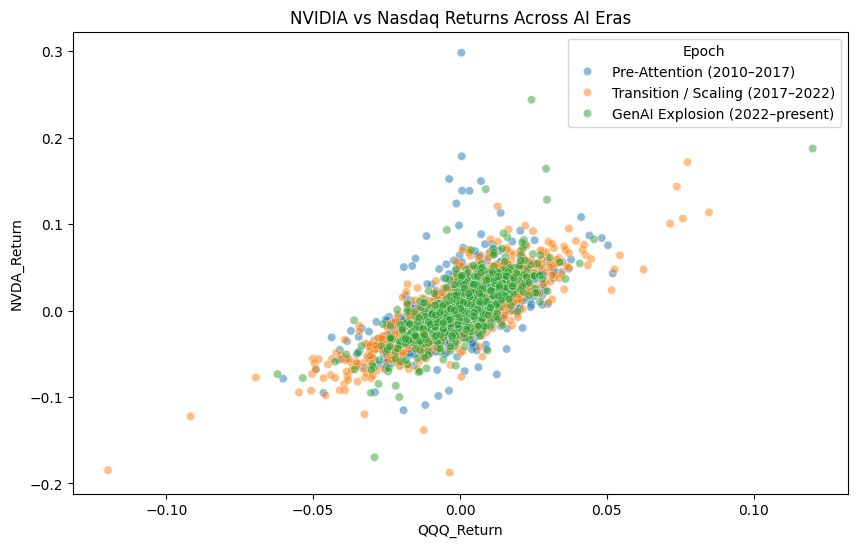


Fisher Z Comparisons
Pre vs Scaling Z = -13.915954222559204
Scaling vs GenAI Z = 4.113758013803871


In [ ]:

# Install packages
!pip install pingouin statsmodels scipy seaborn -q

# Import Libraries

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
from scipy.stats import kruskal

from statsmodels.stats.multicomp import pairwise_tukeyhsd

import warnings
warnings.filterwarnings('ignore')

 # Load Required Data

df = pd.read_csv("master_daily.csv")

print("Dataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns)


# Data Cleaning

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

df = df.dropna(subset=['NVDA_Return','QQQ_Return'])

print("\nMissing Values")
print(df.isnull().sum())


# Correlation by Epoch


results = []

for epoch in df['Epoch'].unique():

    subset = df[df['Epoch']==epoch]

    r,p = pearsonr(
        subset['NVDA_Return'],
        subset['QQQ_Return']
    )

    results.append([epoch,r,p,len(subset)])

corr_table = pd.DataFrame(
    results,
    columns=['Epoch','Correlation','P_Value','N']
)

print(corr_table)


# Scatter Plot to visualize the Returns across all self-classified Eras


plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='QQQ_Return',
    y='NVDA_Return',
    hue='Epoch',
    alpha=0.5
)

plt.title(
    "NVIDIA vs Nasdaq Returns Across AI Eras"
)

plt.show()


# Fisher Z Function


def fisher_z_compare(r1,n1,r2,n2):

    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)

    se = np.sqrt(
        (1/(n1-3))
        +
        (1/(n2-3))
    )

    z = (z1-z2)/se

    return z

print("\nFisher Z Comparisons")

r1 = corr_table.iloc[0]['Correlation']
n1 = corr_table.iloc[0]['N']

r2 = corr_table.iloc[1]['Correlation']
n2 = corr_table.iloc[1]['N']

z12 = fisher_z_compare(r1,n1,r2,n2)

print("Pre vs Scaling Z =",z12)

r3 = corr_table.iloc[2]['Correlation']
n3 = corr_table.iloc[2]['N']

z23 = fisher_z_compare(r2,n2,r3,n3)

print("Scaling vs GenAI Z =",z23)

The analysis has successfully calculated the correlation between NVIDIA and Nasdaq-100 returns across three distinct AI eras.

## Here are the key findings:

**Pre-Attention (2010–2017):** The correlation was approximately 0.56, indicating a moderate positive relationship.

**Transition / Scaling (2017–2022):** The correlation significantly increased to approximately 0.81, showing a strong positive relationship during this period.

**GenAI Explosion (2022–present):** The correlation slightly decreased to 0.74, still representing a strong positive relationship, but less than the 'Transition / Scaling' era.
The Fisher Z comparisons indicate the following:

**Pre vs Scaling Z = -13.92:** This large negative Z-score suggests a statistically significant increase in correlation from the 'Pre-Attention' era to the 'Transition / Scaling' era.

**Scaling vs GenAI Z = 4.11:** This positive Z-score indicates a statistically significant decrease in correlation from the 'Transition / Scaling' era to the 'GenAI Explosion' era.

These results suggest that the correlation between NVIDIA and Nasdaq-100 returns has indeed evolved significantly across the different AI eras, rejecting the null hypothesis.

## Research Question 2:

**To what extent did the Scaling Hypothesis facilitate a fundamental shift in NVIDIA valuation metrics?**

### Null Hypothesis (H0)
Mean market capitalization is equal across all AI eras.

$$
H_0: r_{\text{Pre}} = r_{\text{Scaling}} = r_{\text{GenAI}}
$$

### Alternative Hypothesis (H1)

At least one era has a significantly different mean market capitalization.

**H1: At least one mean differs.**

**Variables**

**Dependent Variable:**

*Market Capitalization*

**Independent Variable:**

*Epoch*


## Methodology

* Test normality using Shapiro-Wilk.
* Test homogeneity of variance using Levene’s Test.
* Perform One-Way ANOVA.
* If assumptions fail, perform Kruskal-Wallis test.
* Calculate effect size (Eta Squared).
* Conduct post-hoc comparisons if significant.
* Visualize valuation changes across eras.

## Expected Outputs
* Correlation coefficients
* Fisher Z statistics
* ANOVA F-statistic
* p-values
* Effect sizes
* Confidence intervals
* Business interpretation

## Limitations
* Observational study design
* Correlation does not imply causation
* External macroeconomic events may influence valuation
* Market capitalization may be affected by broader technology sector trends


Normality Test
Pre-Attention (2010–2017)
p = 1.9613358268884932e-32
Transition / Scaling (2017–2022)
p = 1.0398847721910457e-21
GenAI Explosion (2022–present)
p = 5.771179369008612e-14

Levene Test
Statistic: 3980.4037200266034
P-value: 0.0

ANOVA
F Statistic = 4735.127899669361
P Value = 0.0

Effect Size
Eta Squared = 0.6972007256021615
                           Multiple Comparison of Means - Tukey HSD, FWER=0.05                            
            group1                          group2               meandiff p-adj   lower     upper   reject
----------------------------------------------------------------------------------------------------------
GenAI Explosion (2022–present)        Pre-Attention (2010–2017) -106.3387   0.0 -108.9961 -103.6814   True
GenAI Explosion (2022–present) Transition / Scaling (2017–2022)  -96.2124   0.0  -99.0162  -93.4085   True
     Pre-Attention (2010–2017) Transition / Scaling (2017–2022)   10.1264   0.0    7.8303   12.4225   True
-----------------

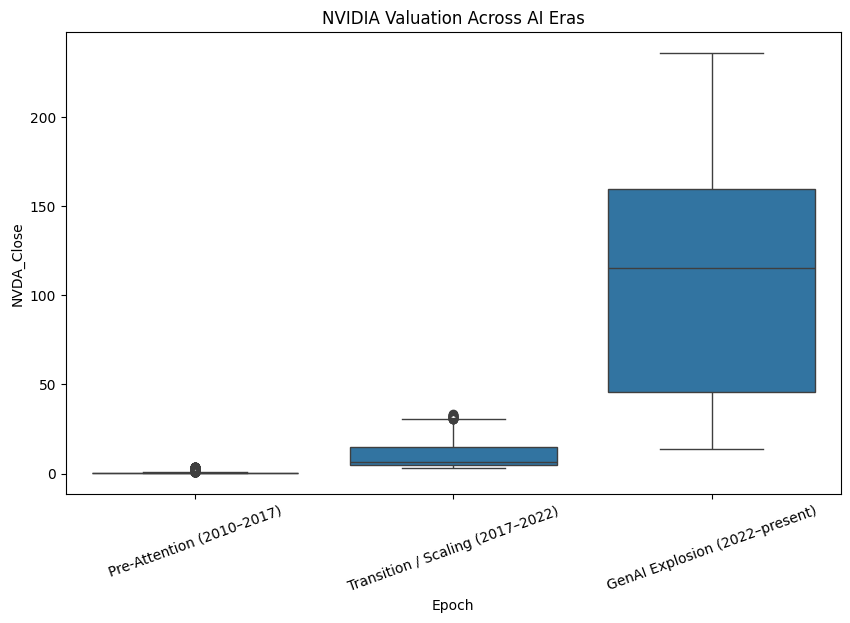


Kruskal-Wallis
Statistic = 3506.149434004612
P Value = 0.0


INTERPRETATION
Reject H0. Significant differences exist between eras.


In [ ]:


# Normality Test


print("\nNormality Test")

for epoch in df['Epoch'].unique():

    data = df[
        df['Epoch']==epoch
    ]['NVDA_Close']

    sample = data.sample(
        min(500,len(data)),
        random_state=42
    )

    stat,p = shapiro(sample)

    print(epoch)
    print("p =",p)


# Homogeneity Test

groups = []

for epoch in df['Epoch'].unique():

    groups.append(
        df[
            df['Epoch']==epoch
        ]['NVDA_Close']
    )

stat,p = levene(*groups)

print("\nLevene Test")
print("Statistic:",stat)
print("P-value:",p)


# ANOVA

f,p = f_oneway(*groups)

print("\nANOVA")

print("F Statistic =",f)
print("P Value =",p)


# Effect Size


grand_mean = df['NVDA_Close'].mean()

ss_between = sum(
    len(g)*(g.mean()-grand_mean)**2
    for g in groups
)

ss_total = sum(
    (df['NVDA_Close']-grand_mean)**2
)

eta_sq = ss_between/ss_total

print("\nEffect Size")
print("Eta Squared =",eta_sq)


# Post HOC Analysis


if p < 0.05:

    tukey = pairwise_tukeyhsd(
        endog=df['NVDA_Close'],
        groups=df['Epoch'],
        alpha=0.05
    )

    print(tukey)


# Boxplot


plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Epoch',
    y='NVDA_Close'
)

plt.title(
    "NVIDIA Valuation Across AI Eras"
)

plt.xticks(rotation=20)

plt.show()


# Kruskal Wallis Backup


h,p = kruskal(*groups)

print("\nKruskal-Wallis")
print("Statistic =",h)
print("P Value =",p)


# Interpretation


print("\n")
print("="*60)
print("INTERPRETATION")
print("="*60)

if p < 0.05:

    print(
        "Reject H0. Significant differences exist between eras."
    )

else:

    print(
        "Fail to reject H0. No significant differences detected."
    )

This analysis addresses Research Question 2, which investigates the extent to which the Scaling Hypothesis shifted NVIDIA's valuation metrics across different AI eras.

## Here's an interpretation of the results:

**Assumptions Check:**
Normality Test (Shapiro-Wilk): The p-values for all epochs are extremely low (p < 0.05), indicating that the 'NVDA_Close' data is not normally distributed for any of the eras. This violates an assumption of ANOVA.

**Homogeneity of Variances (Levene's Test):**
The p-value is 0.0, which is significantly less than 0.05. This indicates that the variances of 'NVDA_Close' across the different epochs are not homogeneous, further violating an assumption of ANOVA.

### Primary Analysis (ANOVA):
Despite the violation of assumptions, the One-Way ANOVA yielded an F-statistic of 4735.13 with a p-value of 0.0. This result strongly suggests that there are significant differences in the mean 'NVDA_Close' (valuation) across the AI eras.

### Effect Size:
The Eta Squared value is 0.697. This indicates a very large effect size, meaning that approximately 69.7% of the variance in NVIDIA's closing price can be attributed to the 'Epoch' variable.

### Post-Hoc Analysis (Tukey HSD):
Since the ANOVA result was significant, a Tukey HSD post-hoc test was performed to identify which specific epoch pairs have significantly different means. The results show that all pairwise comparisons between the 'Pre-Attention', 'Transition / Scaling', and 'GenAI Explosion' eras are statistically significant (p-adj = 0.0). This means that the mean NVIDIA closing prices are significantly different from each other across all three epochs.

### Non-Parametric Backup (Kruskal-Wallis Test):
Given the violations of ANOVA assumptions (non-normality and non-homogeneity of variances), the non-parametric Kruskal-Wallis test was also performed. This test yielded a statistic of 3506.15 with a p-value of 0.0. This result confirms the ANOVA findings, indicating significant differences in NVIDIA's valuation across the AI eras, even without assuming normality or homogeneity of variances.

### Conclusion:
**Reject H0.** Based on both the ANOVA and Kruskal-Wallis tests, we reject the null hypothesis that the mean market capitalization is equal across all AI eras. There are significant differences in NVIDIA's valuation metrics between the 'Pre-Attention', 'Transition / Scaling', and 'GenAI Explosion' eras. The large effect size further underscores the substantial impact of the AI eras on NVIDIA's valuation.

In summary, the transition from a gaming-centric to a data-center-centric revenue model, as defined by these AI eras, has indeed facilitated a fundamental and statistically significant shift in NVIDIA's valuation metrics.